<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 2: Modelizando un ADC**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 09/09/2026  

---

### **Introducción**
Para poder procesar cualquier señal analógica en una computadora o un microcontrolador, primero necesitamos pasarla al mundo digital. De este trabajo se encarga el Conversor Analógico-Digital (ADC), que básicamente hace dos cosas: toma muestras de la señal cada cierto tiempo (muestreo a una frecuencia $f_s$) y redondea esos valores de voltaje a un conjunto finito de niveles discretos (cuantización usando $B$ bits dentro de un rango de $\pm V_F$ Volts). Este proceso de redondeo define el paso de cuantización ($q$), que representa el escalón mínimo de tensión (o LSB) que el conversor es capaz de resolver. Este paso se calcula como: $$q = \frac{V_R}{2^B}$$ Donde $V_R$ es el rango de tensión de referencia del conversor (que para nuestra simulación vale $2.0\text{ V}$) y $B$ es la cantidad de bits de resolución 

<br>

Como en la práctica ninguna señal analógica es perfecta y siempre vienen con interferencias, en este trabajo vamos a simular una señal de entrada real sumándole a una senoidal pura un ruido blanco de tipo Gaussiano: $s_R[n] = s[n] + n[n]$. Lo interesante de la simulación es cómo calibramos ese ruido de entrada: para poder comparar el ruido "externo" (el analógico) con el ruido propio de redondeo que mete el ADC, definimos la potencia del ruido analógico ($P_n$) como un múltiplo de la potencia de cuantización teórica ($P_q = q^2/12$): $$P_n = k_n \cdot P_q$$ Donde $k_n$ es el factor de escala que nos va a permitir analizar qué ruido es el que termina arruinando la señal.

### **Objetivos**
El objetivo de esta tarea semanal es simular y modelar en Python el comportamiento de un ADC bipolar de $\pm 2\text{ V}$ con una frecuencia de muestreo de $1000\text{ Hz}$. Para ver cómo responde el sistema, vamos a ir cambiando y cruzando dos variables clave: la resolución del conversor ($B = \{4, 8, 16\}$ bits) y la cantidad de ruido aditivo ($k_n = \{0.1, 1, 10\}$).

### **Codigo Completo**

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def simular(bits_adc, escala_ruido):
    frecuencia_muestreo = 1000.0  # Frecuencia fs (1000 Hz)
    cant_muestras = 1000          # Muestras N
    v_rango = 2.0                 # Rango V_R (+/- 2.0 V)

    tiempo = np.arange(cant_muestras) / frecuencia_muestreo

    # Paso de cuantización (q = V_R / 2^B)
    paso_cuantizacion = v_rango / (2**bits_adc)

    # GENERACIÓN DE SEÑALES
    frec_fundamental = frecuencia_muestreo / cant_muestras
    senoidal_pura = np.sqrt(2) * np.sin(2 * np.pi * frec_fundamental * tiempo)

    # Potencias teóricas de ruido
    potencia_cuantizacion = (paso_cuantizacion**2) / 12
    potencia_ruido_analogico = escala_ruido * potencia_cuantizacion

    # Ruido analógico n(t)
    ruido_analogico = np.random.normal(0, np.sqrt(potencia_ruido_analogico), cant_muestras)

    # Señal s_R(t) = s(t) + n(t)
    senal_contaminada = senoidal_pura + ruido_analogico

    # CUANTIZACIÓN (ADC) Y ERROR
    senal_cuantizada = paso_cuantizacion * np.round(senal_contaminada / paso_cuantizacion)
    senal_cuantizada = np.clip(senal_cuantizada, -v_rango, v_rango - paso_cuantizacion)
    error_cuantizacion = senal_cuantizada - senal_contaminada

    # ANÁLISIS ESPECTRAL (PSD) Y PISOS DE RUIDO
    fft_pura = np.fft.rfft(senoidal_pura) / cant_muestras
    fft_contaminada = np.fft.rfft(senal_contaminada) / cant_muestras
    fft_cuantizada = np.fft.rfft(senal_cuantizada) / cant_muestras

    psd_pura = np.abs(fft_pura)**2
    psd_contaminada = np.abs(fft_contaminada)**2
    psd_cuantizada = np.abs(fft_cuantizada)**2

    psd_pura[1:-1] *= 2
    psd_contaminada[1:-1] *= 2
    psd_cuantizada[1:-1] *= 2

    psd_pura_db = 10 * np.log10(psd_pura + 1e-12)
    psd_contaminada_db = 10 * np.log10(psd_contaminada + 1e-12)
    psd_cuantizada_db = 10 * np.log10(psd_cuantizada + 1e-12)

    frecuencias = np.fft.rfftfreq(cant_muestras, d=1/frecuencia_muestreo)

    piso_analogico_db = 10 * np.log10(potencia_ruido_analogico / (cant_muestras / 2))
    piso_digital_db = 10 * np.log10(potencia_cuantizacion / (cant_muestras / 2))

    # VISUALIZACIÓN
    # --- Gráfico 1: Dominio del Tiempo ---
    plt.figure(figsize=(10, 4))
    plt.plot(tiempo, senal_cuantizada, label=r"$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)", color="tab:blue", lw=1.5)
    plt.plot(tiempo, senal_contaminada, color="green", linestyle=":", marker="o", markersize=2, label=r"$s_R = s + n$ (ADC in)", alpha=0.7)
    plt.plot(tiempo, senoidal_pura, color="orange", linestyle="--", label=r"$s$ (analog)", lw=1.2)
    plt.title(rf"Señal muestreada por un ADC de {bits_adc} bits - $\pm V_R = {v_rango}\text{{ V}} - q = {paso_cuantizacion}\text{{ V}}$")
    plt.xlabel("tiempo [segundos]")
    plt.ylabel("Amplitud [V]")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Densidad Espectral de Potencia (PSD) ---
    plt.figure(figsize=(10, 4))
    plt.plot(frecuencias, psd_cuantizada_db, color="tab:blue", lw=1.0, label=r"$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)")
    plt.plot(frecuencias, psd_pura_db, color="orange", linestyle="--", lw=1.0, label=r"$s$ (analog)")
    plt.plot(frecuencias, psd_contaminada_db, color="green", linestyle=":", alpha=0.6, label=r"$s_R = s + n$ (ADC in)")
    plt.axhline(piso_analogico_db, color="red", linestyle="--", label=rf"$\overline{{n}} = {piso_analogico_db:.1f}\text{{ dB}}$ (piso analog.)")
    plt.axhline(piso_digital_db, color="cyan", linestyle="--", label=rf"$\overline{{n}}_Q = {piso_digital_db:.1f}\text{{ dB}}$ (piso digital)")
    plt.title(rf"Señal muestreada por un ADC de {bits_adc} bits - $\pm V_R = {v_rango}\text{{ V}} - q = {paso_cuantizacion}\text{{ V}}$")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Densidad de Potencia [dB]")
    piso_minimo = min(piso_analogico_db, piso_digital_db)
    plt.ylim(piso_minimo - 10, 10)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Gráfico 3: Histograma del Error ---
    plt.figure(figsize=(10, 4))
    plt.hist(error_cuantizacion, bins=10, color="tab:blue", edgecolor="white")
    plt.plot([-paso_cuantizacion/2, -paso_cuantizacion/2, paso_cuantizacion/2, paso_cuantizacion/2], [0, 100, 100, 0], 'r--', lw=1.5)
    plt.xlabel("Error de cuantización $e_q$ [V]") 
    plt.ylabel("Cantidad de muestras")
    plt.title(rf"Ruido de cuantización para {bits_adc} bits - $\pm V_R = {v_rango}\text{{ V}} - q = {paso_cuantizacion}\text{{ V}}$")
    plt.xlim(-paso_cuantizacion, paso_cuantizacion)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

<br>

$B = 4$ y $k_n = 1$

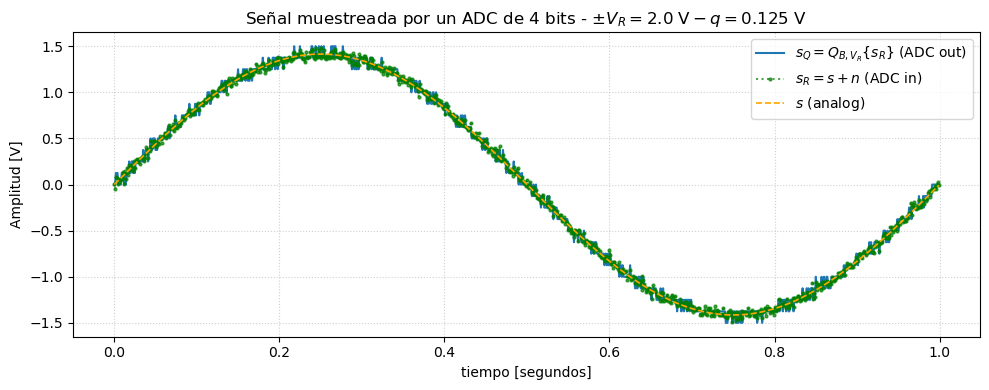

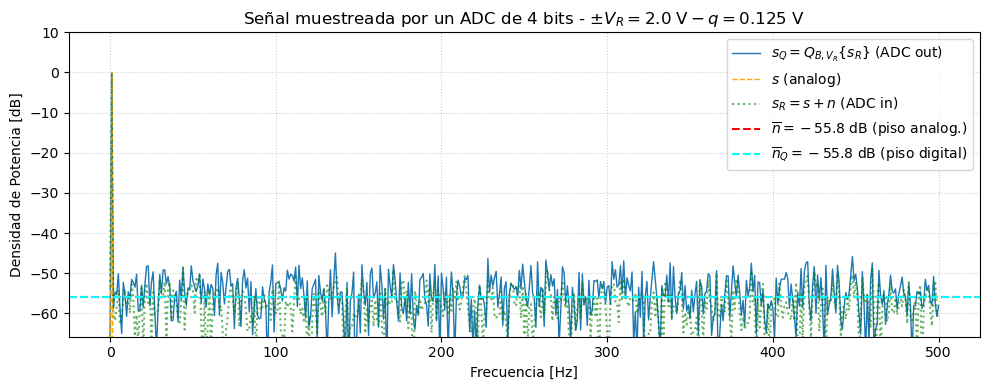

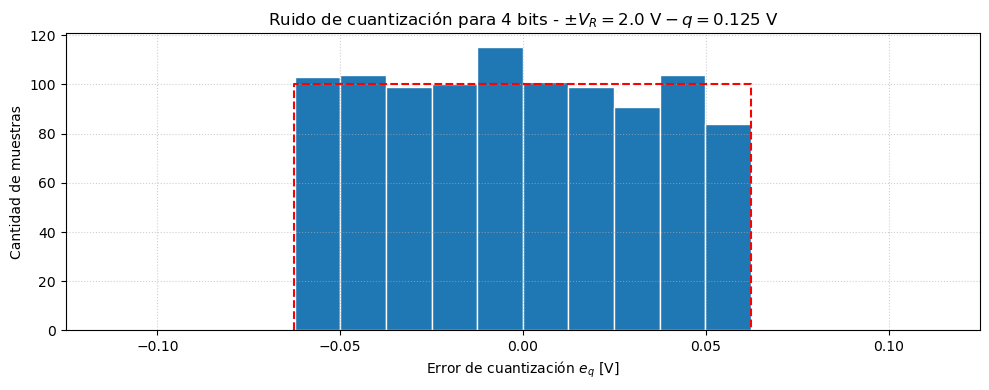

In [15]:
simular(bits_adc=4, escala_ruido=1.0)

<br>

$B = 4$ y $k_n = 0.1$

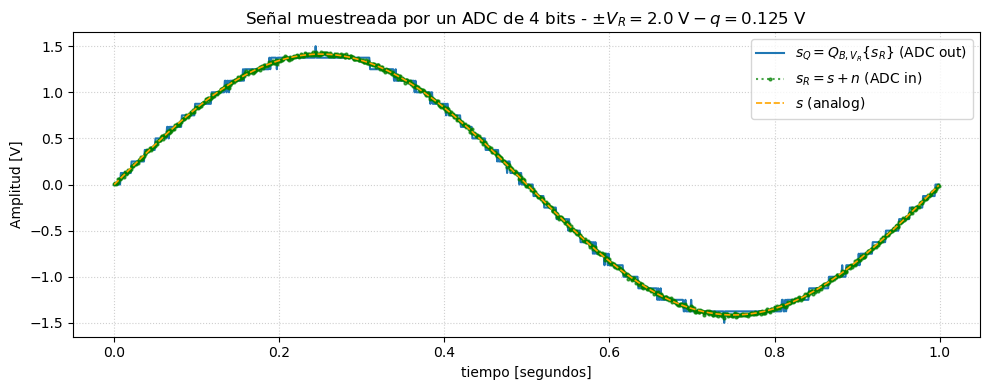

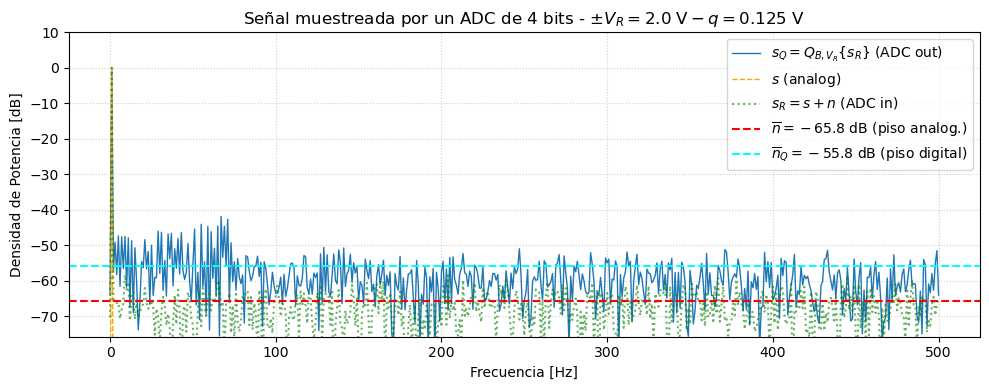

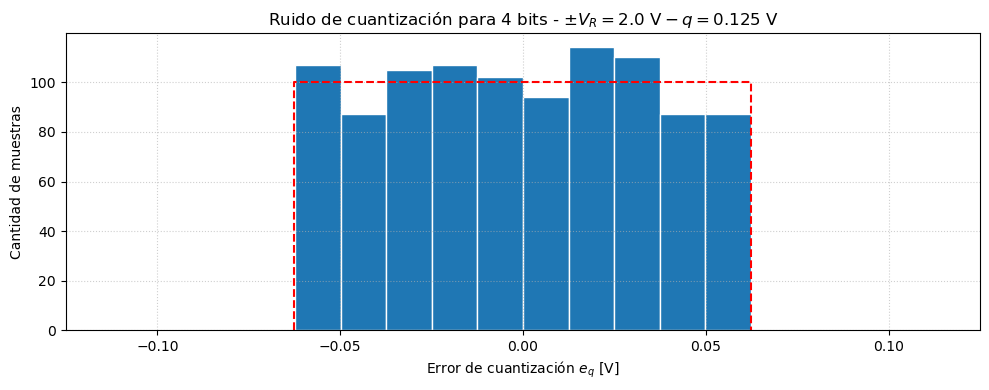

In [14]:
simular(bits_adc=4, escala_ruido=0.1)

<br>

$B = 4$ y $k_n = 10$

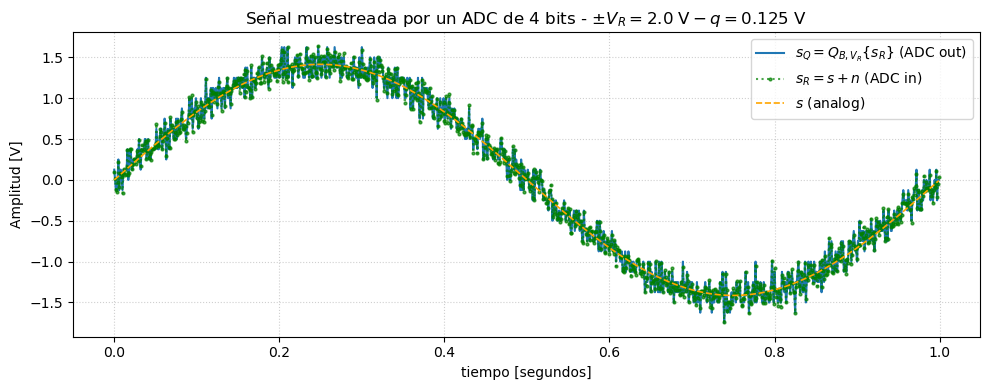

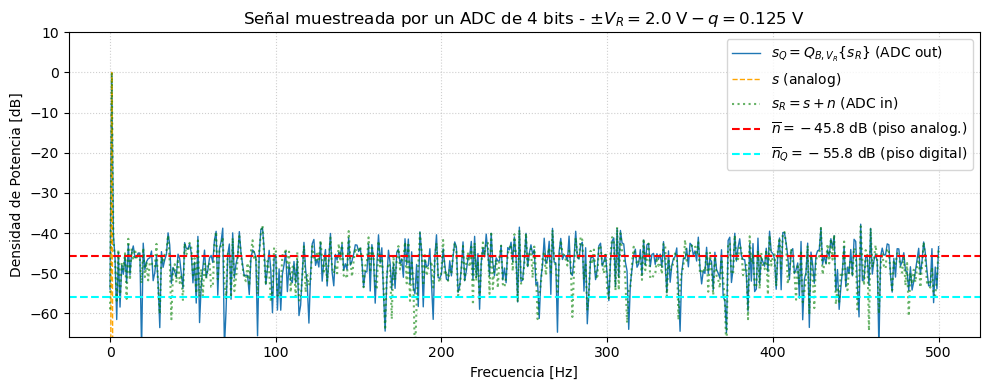

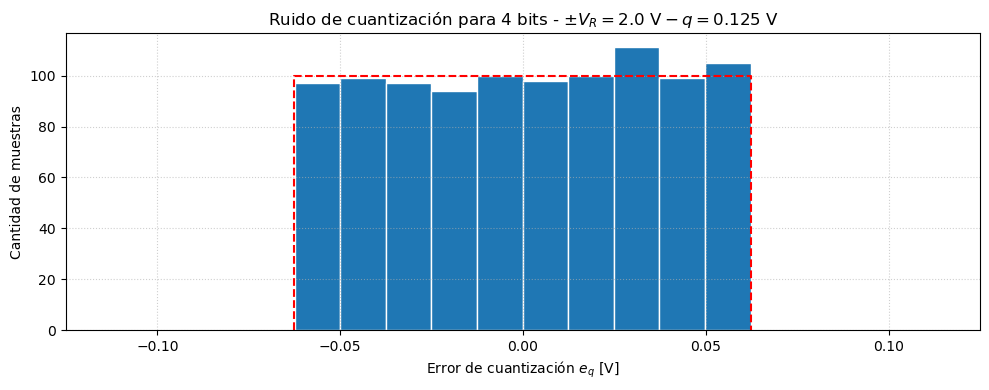

In [13]:
simular(bits_adc=4, escala_ruido=10)

<br>

$B = 8$ y $k_n = 0.1$

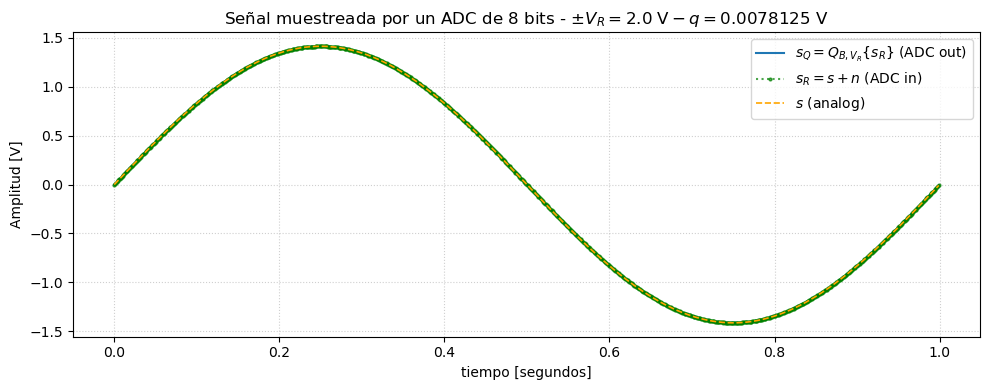

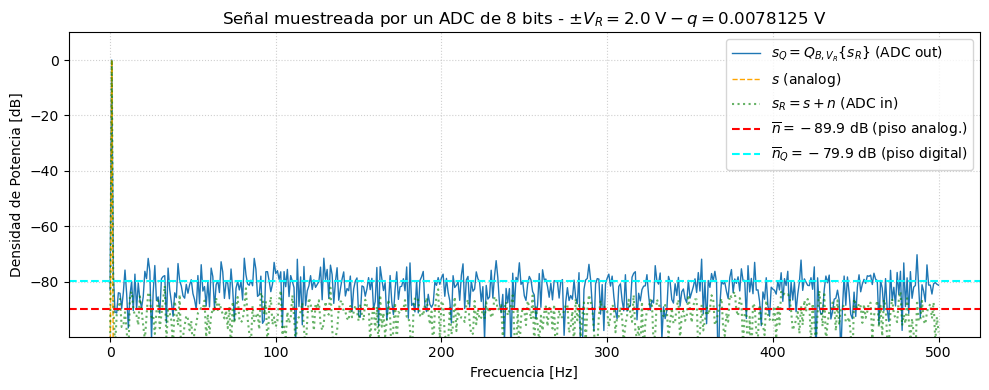

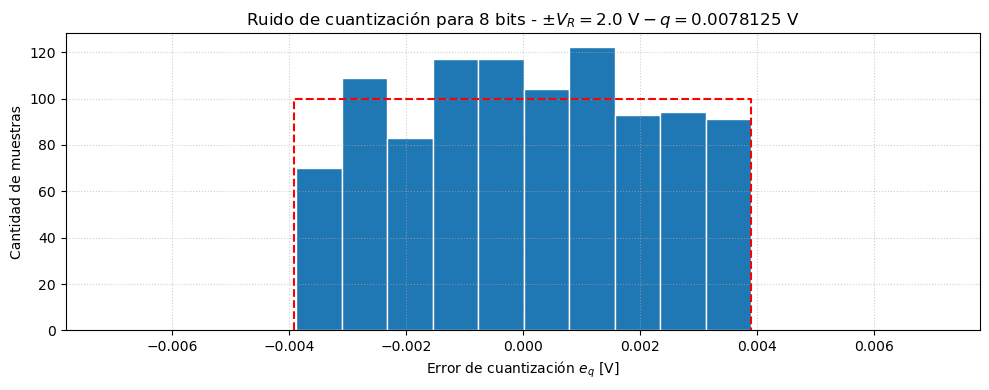

In [12]:
simular(bits_adc=8, escala_ruido=0.1)

<br>

$B = 8$ y $k_n = 1$

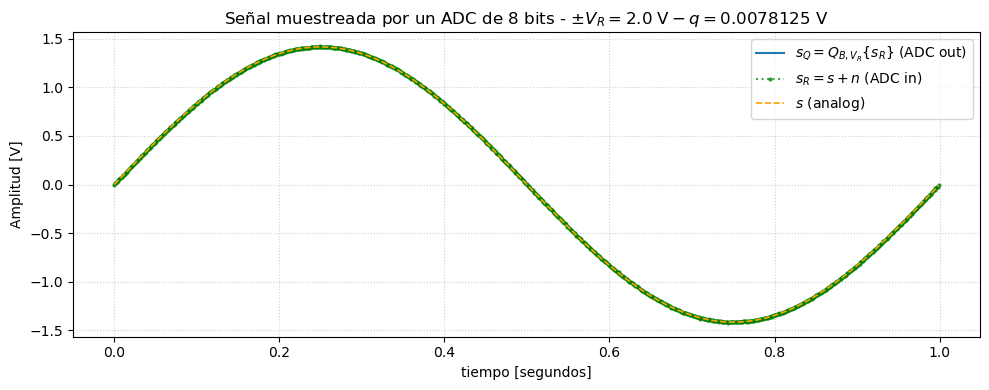

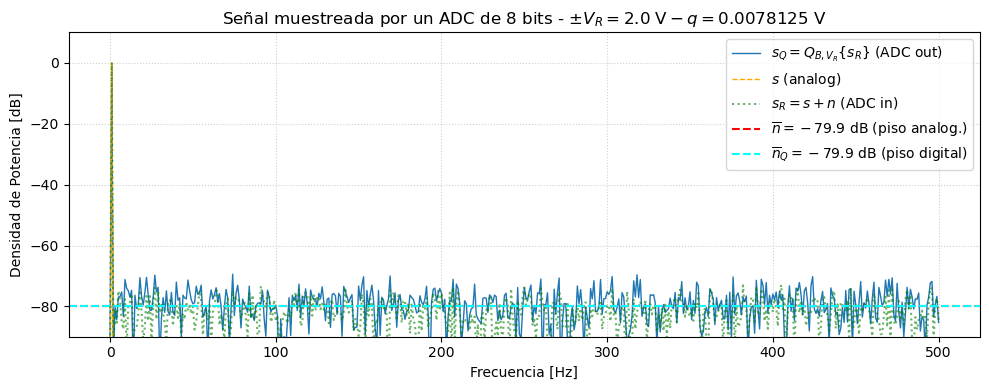

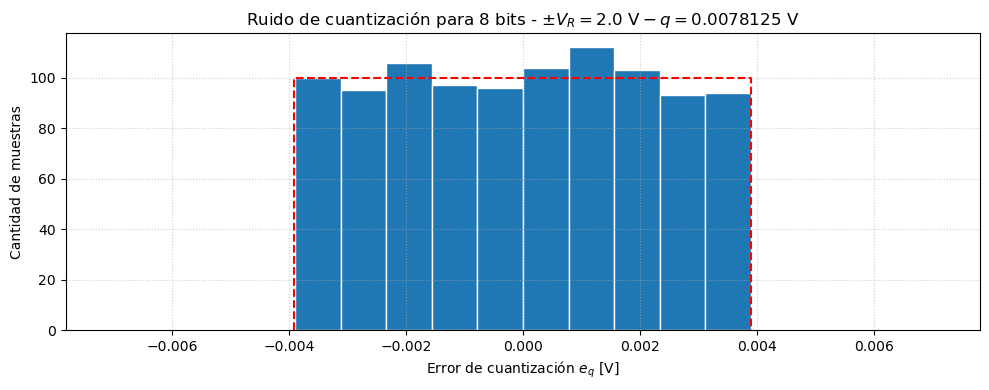

In [16]:
simular(bits_adc=8, escala_ruido=1)

<br>

$B = 8$ y $k_n = 10$

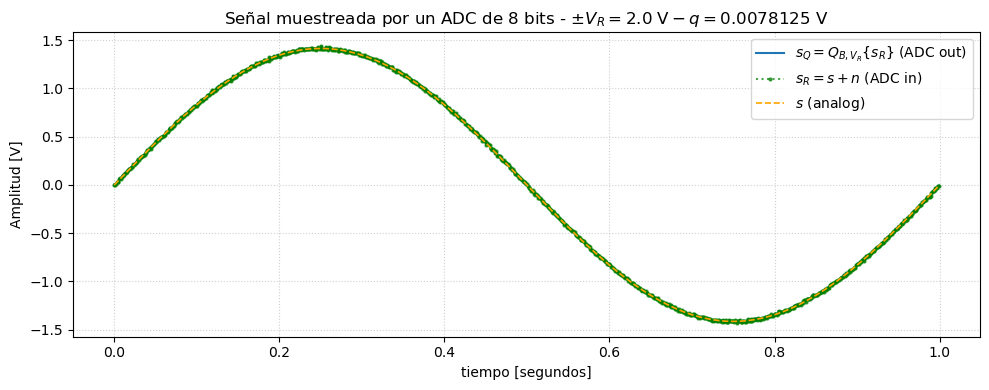

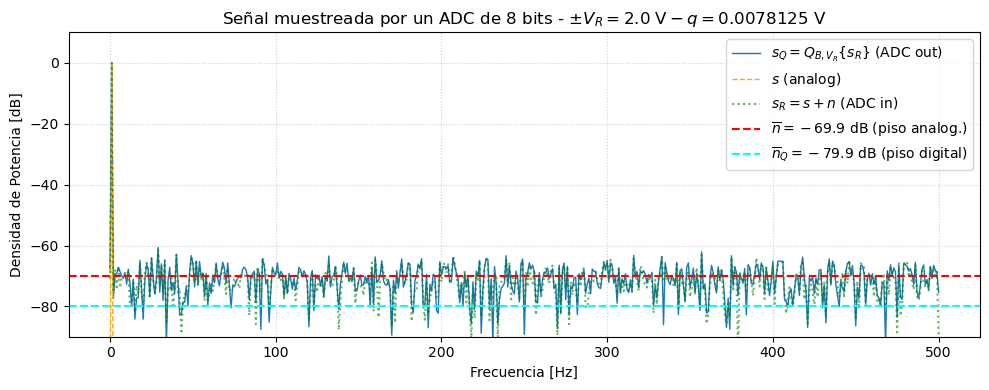

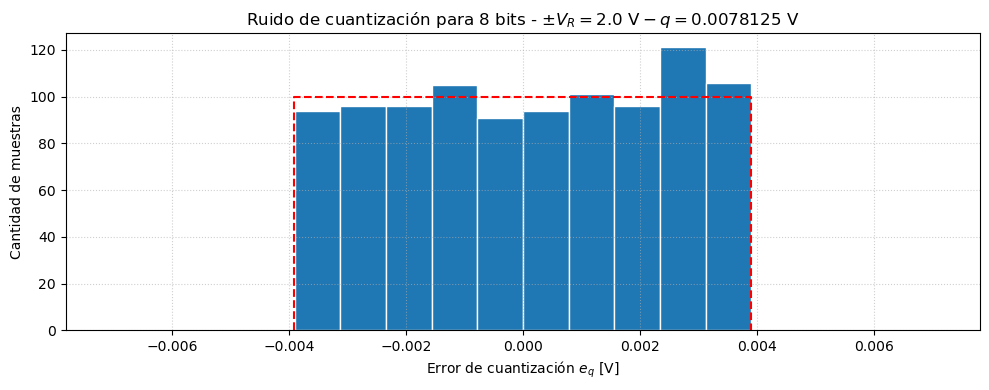

In [17]:
simular(bits_adc=8, escala_ruido=10)

<br>

$B = 16$ y $k_n = 0.1$

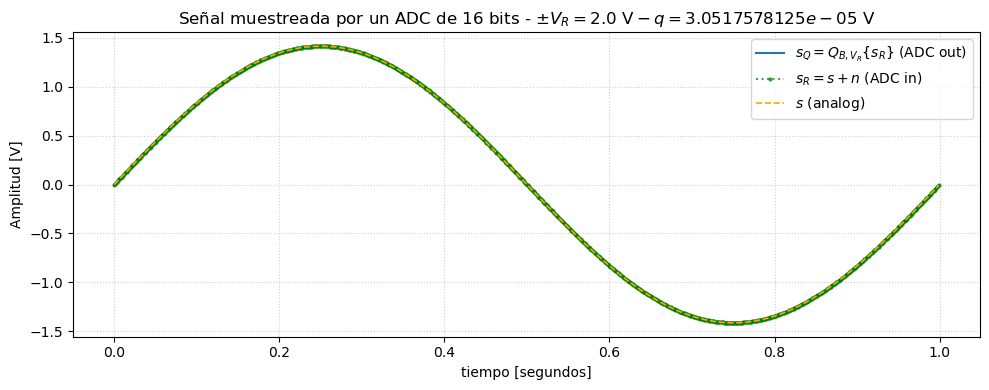

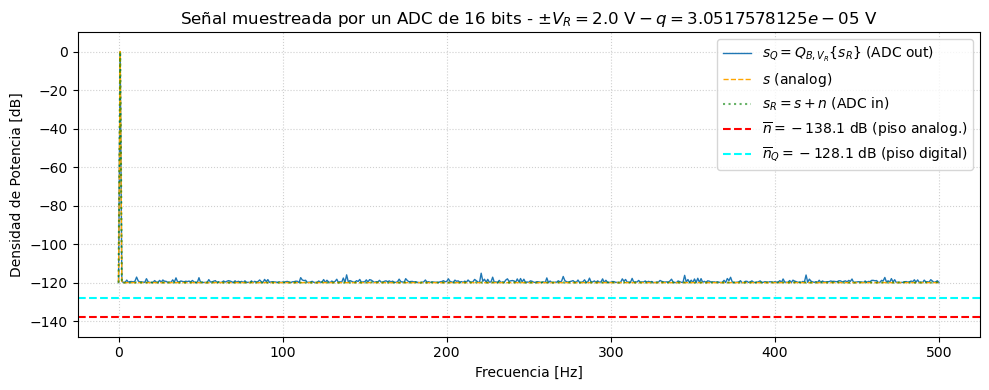

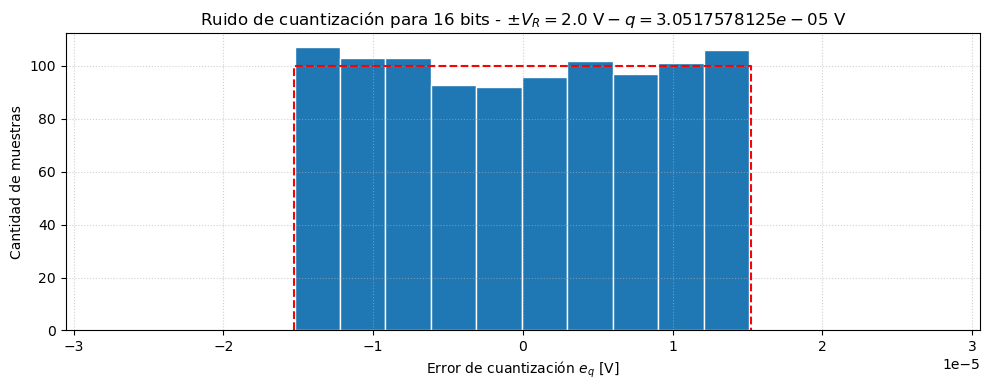

In [19]:
simular(bits_adc=16, escala_ruido=0.1)

<br>

$B = 16$ y $k_n = 1$

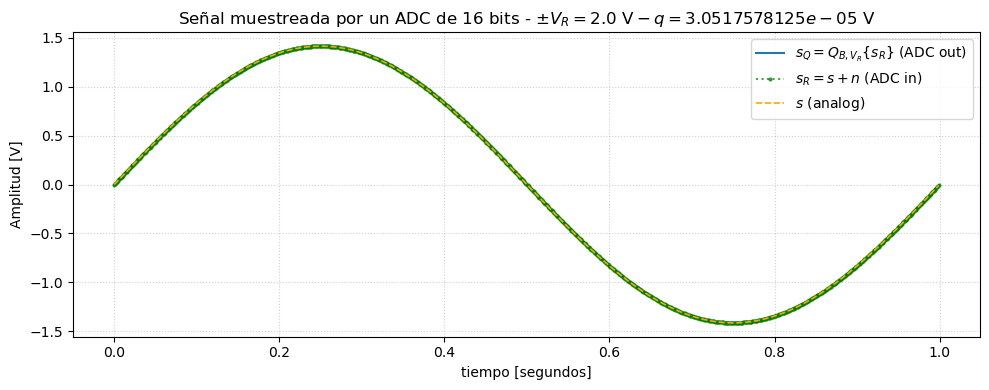

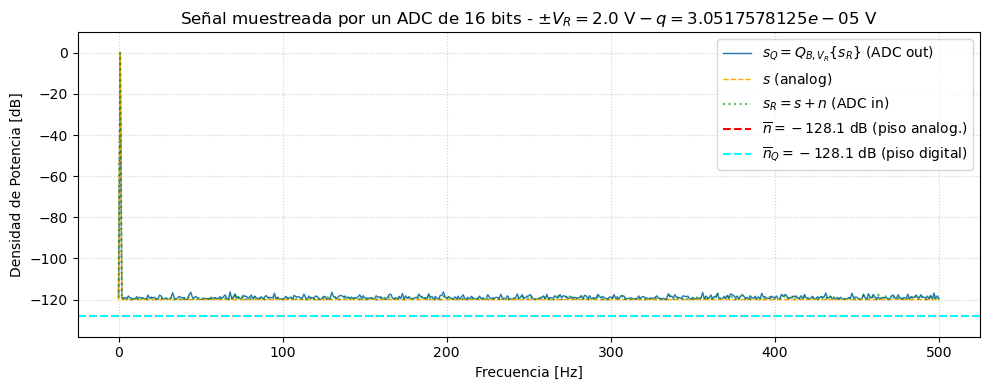

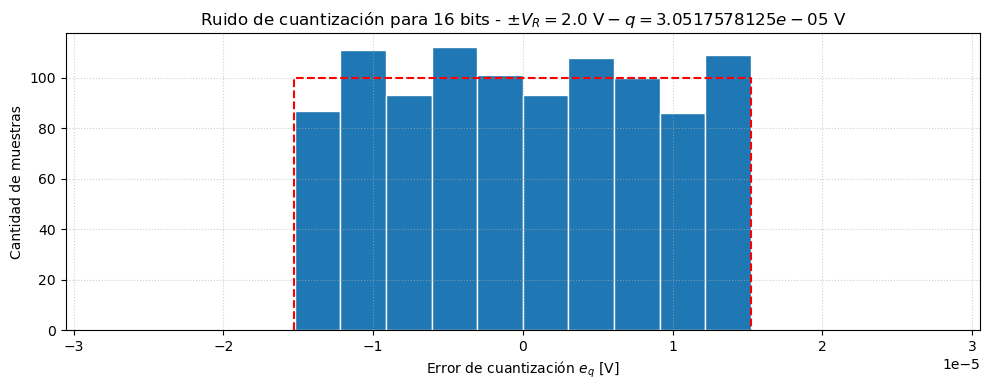

In [20]:
simular(bits_adc=16, escala_ruido=1)

<br>

$B = 16$ y $k_n = 10$

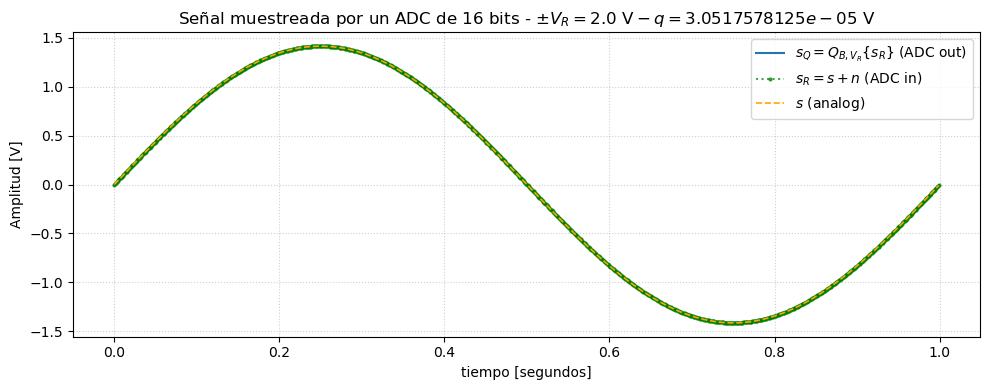

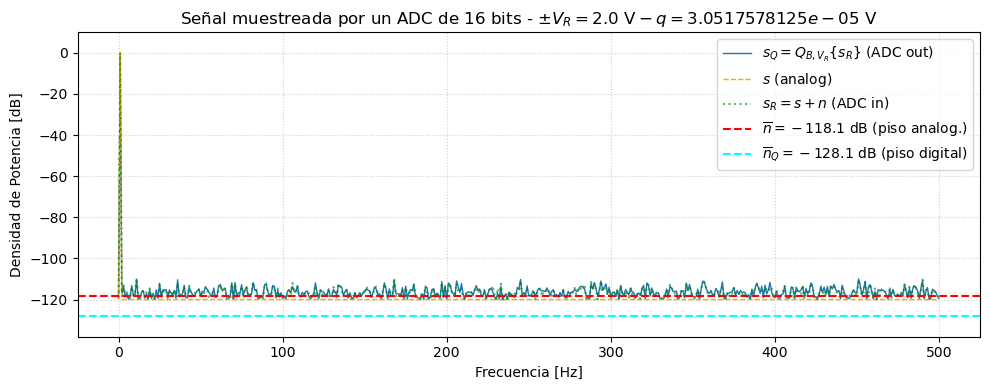

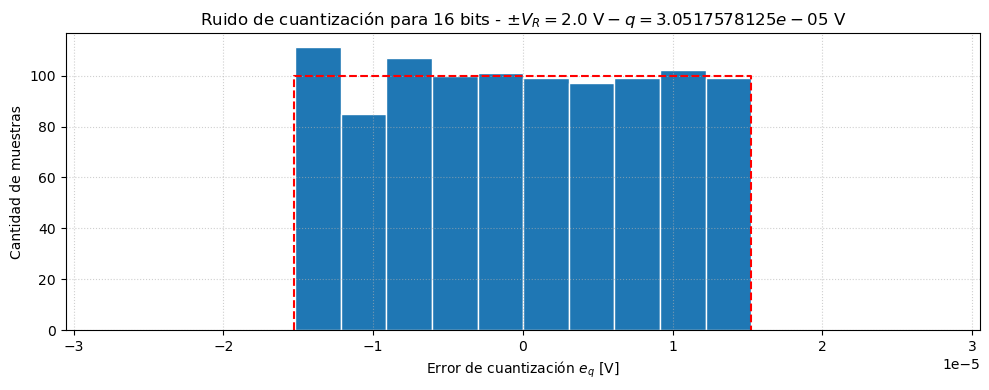

In [21]:
simular(bits_adc=16, escala_ruido=10)

### **Análisis de Resultados** 

